# EDA

EDA pentru dataset-ul final unificat: `Severstal + NEU-DET + Kolektor`.

Obiective:
- verificarea merge-ului dintre cele 3 surse
- distributia imaginilor curate vs defecte
- distributia pe clasele finale `Class_1..Class_4`
- analiza ariilor de defect si a dezechilibrului
- exemple vizuale 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from utils import (
    SEED,
    build_mask_from_record,
    build_merged_metadata,
    compute_mask_area_table,
    get_dataset_roots,
    load_image_as_rgb,
    overlay_multiclass_mask,
    seed_everything,
    summarize_class_balance,
    summarize_merged_metadata,
)

seed_everything(SEED)
sns.set_theme(style='whitegrid')

In [23]:
BASE = Path("/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava")

utils.SEVERSTAL_ROOT = BASE / "severstal-steel-defect-detection"
utils.NEU_ROOT = BASE / "NEU-DET_data"
utils.KOLEKTOR_ROOT = BASE / "kolektor_data"

utils.TRAIN_DIR = f'{utils.SEVERSTAL_ROOT}/train_images'
utils.TRAIN_CSV = f'{utils.SEVERSTAL_ROOT}/train.csv'
utils.TEST_DIR = f'{utils.SEVERSTAL_ROOT}/test_images'

utils.build_severstal_metadata.__defaults__ = (
    utils.TRAIN_CSV,
    utils.TRAIN_DIR
)

build_severstal_metadata = utils.build_severstal_metadata

metadata = build_merged_metadata(refresh_cache=True, cache_path="/kaggle/working/merged_metadata.csv")
summary = summarize_merged_metadata(metadata)
class_balance = summarize_class_balance(metadata)

print('Seed:', SEED)
print('Dataset roots:', get_dataset_roots())
print('Total images:', len(metadata))
print('Sources:', metadata['source'].value_counts().to_dict())
summary

Seed: 1335
Dataset roots: {'severstal': '/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava/severstal-steel-defect-detection', 'neu': '/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava/NEU-DET_data', 'kolektor': '/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava/kolektor_data'}
Total images: 17102
Sources: {'severstal': 12568, 'kolektor': 3335, 'neu': 1199}


,source,source_split,images,defect_images,clean_images,weak_labels,class_1_images,class_2_images,class_3_images,class_4_images
0,kolektor,test,1004,110,894,0,0,0,0,110
1,kolektor,train,2331,246,2085,0,0,0,0,246
2,neu,train,959,959,0,959,239,265,268,240
3,neu,validation,240,240,0,240,60,68,73,60
4,severstal,official_train,12568,6666,5902,0,897,247,5150,801


/tmp/ipykernel_55/3531680413.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_balance, x='class_id', y='images_with_class', ax=axes[1], palette='viridis')


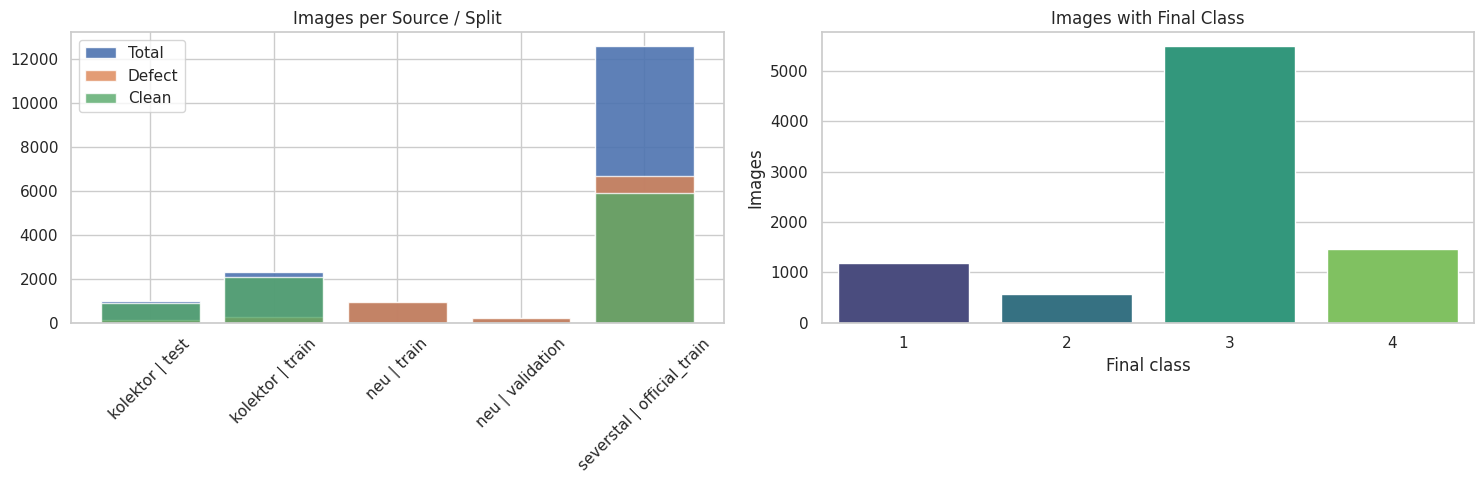

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

summary_plot = summary.copy()
summary_plot['bucket'] = summary_plot['source'] + ' | ' + summary_plot['source_split']
summary_plot = summary_plot.sort_values(['source', 'source_split'])

axes[0].bar(summary_plot['bucket'], summary_plot['images'], label='Total', alpha=0.9)
axes[0].bar(summary_plot['bucket'], summary_plot['defect_images'], label='Defect', alpha=0.8)
axes[0].bar(summary_plot['bucket'], summary_plot['clean_images'], label='Clean', alpha=0.8)
axes[0].set_title('Images per Source / Split')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

sns.barplot(data=class_balance, x='class_id', y='images_with_class', ax=axes[1], palette='viridis')
axes[1].set_title('Images with Final Class')
axes[1].set_xlabel('Final class')
axes[1].set_ylabel('Images')

plt.tight_layout()
plt.savefig('eda_dataset_overview.png', dpi=150)
plt.show()

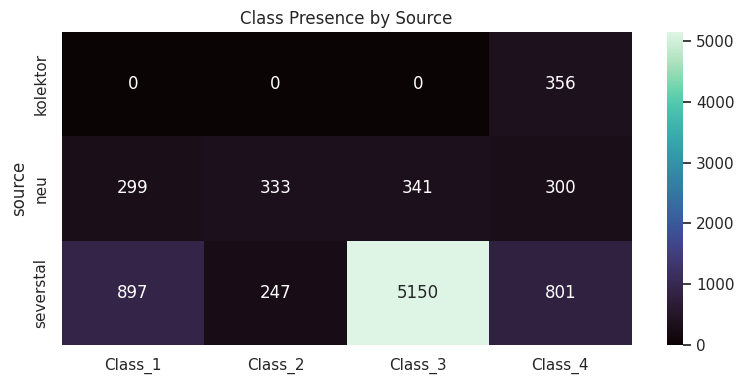

,Class_1,Class_2,Class_3,Class_4
source,,,,
kolektor,0,0,0,356
neu,299,333,341,300
severstal,897,247,5150,801


In [25]:
presence_cols = [f'class_{idx}_present' for idx in range(1, 5)]
presence_by_source = (
    metadata.groupby('source')[presence_cols]
    .sum()
    .rename(columns={f'class_{idx}_present': f'Class_{idx}' for idx in range(1, 5)})
)

plt.figure(figsize=(8, 4))
sns.heatmap(presence_by_source, annot=True, fmt='.0f', cmap='mako')
plt.title('Class Presence by Source')
plt.tight_layout()
plt.savefig('eda_class_presence_by_source.png', dpi=150)
plt.show()

presence_by_source

/tmp/ipykernel_55/2235759436.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=area_table, x='class_name', y='share_pct', ax=axes[0], palette='crest', showfliers=False)
/tmp/ipykernel_55/2235759436.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=area_table, x='source', y='share_pct', ax=axes[1], palette='flare', showfliers=False)


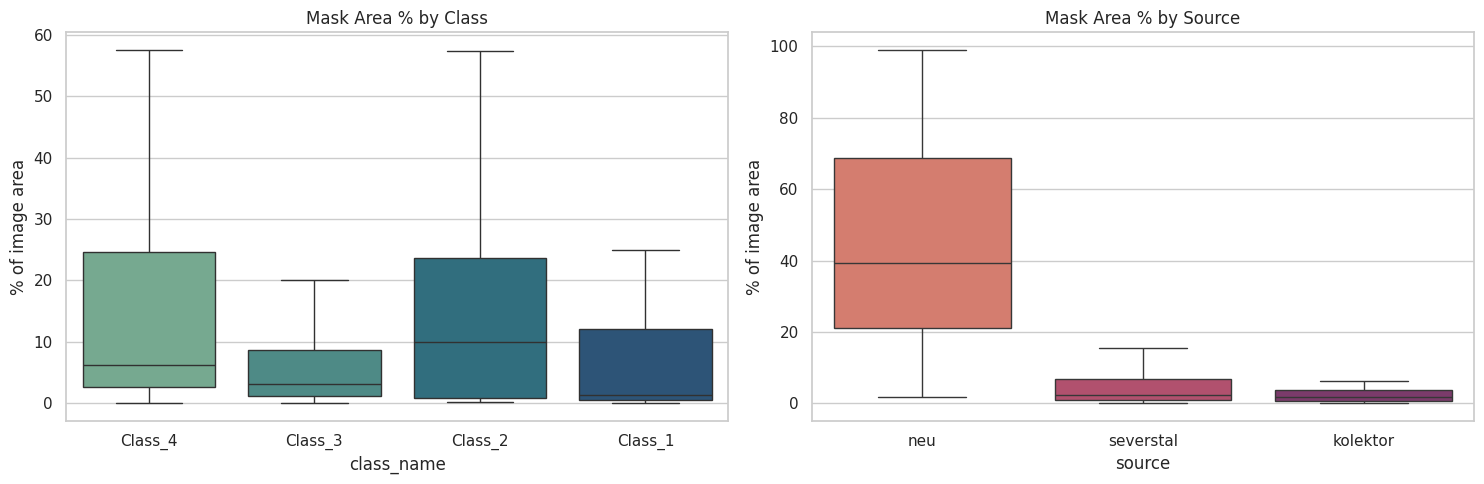

count     mean   median
source    class_name                         
kolektor  Class_4        51   3.3158   1.6442
neu       Class_1        45  53.0703  54.3900
          Class_2        57  23.0266  21.3425
          Class_3        43  30.1802  28.6500
          Class_4        47  81.1621  89.1800
severstal Class_1       130   1.0932   0.9396
          Class_2        38   0.7518   0.7220
          Class_3       763   6.3037   2.9370
          Class_4        99   7.4441   5.7126

In [26]:
area_table = compute_mask_area_table(metadata, max_samples=2500)
area_table = area_table[area_table['pixels'] > 0].copy()
area_table['class_name'] = area_table['class_id'].map(lambda x: f'Class_{x}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=area_table, x='class_name', y='share_pct', ax=axes[0], palette='crest', showfliers=False)
axes[0].set_title('Mask Area % by Class')
axes[0].set_ylabel('% of image area')

sns.boxplot(data=area_table, x='source', y='share_pct', ax=axes[1], palette='flare', showfliers=False)
axes[1].set_title('Mask Area % by Source')
axes[1].set_ylabel('% of image area')

plt.tight_layout()
plt.savefig('eda_mask_area_distributions.png', dpi=150)
plt.show()

area_table.groupby(['source', 'class_name'])['share_pct'].agg(['count', 'mean', 'median']).round(4)

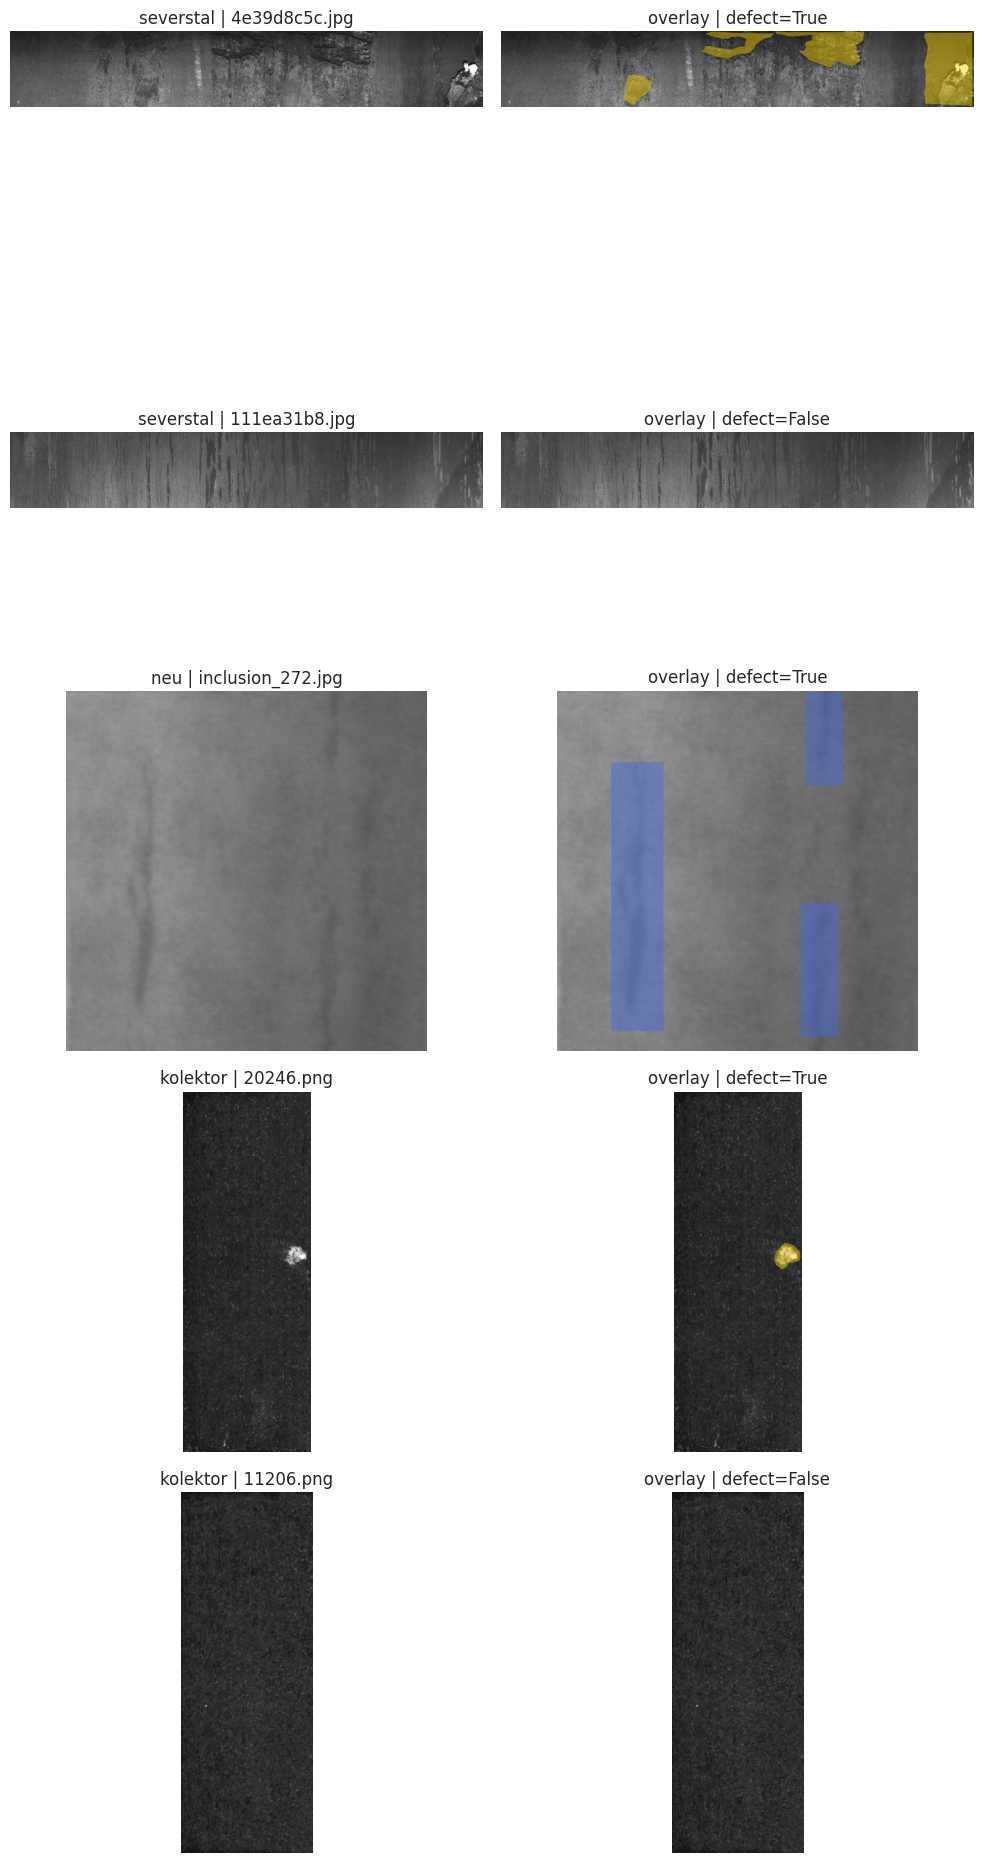

In [27]:
sample_rows = []
for source in ['severstal', 'neu', 'kolektor']:
    source_df = metadata[metadata['source'] == source]
    defect_df = source_df[source_df['has_defect']]
    clean_df = source_df[~source_df['has_defect']]
    if len(defect_df):
        sample_rows.append(defect_df.sample(1, random_state=SEED).iloc[0].to_dict())
    if len(clean_df):
        sample_rows.append(clean_df.sample(1, random_state=SEED).iloc[0].to_dict())

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(10, 4 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, record in enumerate(sample_rows):
    image = load_image_as_rgb(record['image_path'])
    mask = build_mask_from_record(record)
    overlay = overlay_multiclass_mask(image, mask)

    axes[row_idx, 0].imshow(image, cmap='gray')
    axes[row_idx, 0].set_title(f"{record['source']} | {record['ImageId']}")
    axes[row_idx, 1].imshow(overlay)
    axes[row_idx, 1].set_title(f"overlay | defect={record['has_defect']}")

    axes[row_idx, 0].axis('off')
    axes[row_idx, 1].axis('off')

plt.tight_layout()
plt.savefig('eda_source_samples.png', dpi=150)
plt.show()

In [28]:
summary.to_csv('eda_source_summary.csv', index=False)
class_balance.to_csv('eda_class_balance.csv', index=False)
area_table.to_csv('eda_mask_area_table.csv', index=False)
print('Saved: eda_source_summary.csv, eda_class_balance.csv, eda_mask_area_table.csv')

Saved: eda_source_summary.csv, eda_class_balance.csv, eda_mask_area_table.csv
